<a href="https://colab.research.google.com/github/Khushi310105/Final_Year_Project/blob/main/IddTdc_Conv1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install mne
!unzip "/content/drive/MyDrive/Colab Notebooks/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus.zip" -d .

In [3]:
from glob import glob
import scipy.io
import numpy as np
import mne

In [4]:
IDD_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest'
TDC_data_path='/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_TDC/Rest'
!rm '/content/EEG dataset of individuals with intellectual and developmental disorder and healthy controls while observing rest and musical stimulus/Data/CleanData/CleanData_IDD/Rest/NDS001_Rest_CD(1).mat'

In [5]:
def convertmat2mne(data):
  ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
  ch_types = ['eeg'] * 14
  sampling_freq=128
  info = mne.create_info(ch_names, ch_types=ch_types, sfreq=sampling_freq)
  info.set_montage('standard_1020')
  data=mne.io.RawArray(data, info)
  data.set_eeg_reference()
  data.filter(l_freq=1,h_freq=30)
  epochs=mne.make_fixed_length_epochs(data,duration=4,overlap=0)
  return epochs.get_data()


In [6]:
%%capture
idd_subject=[]
for idd in glob(IDD_data_path+'/*.mat'):
  data=scipy.io.loadmat(idd)['clean_data']
  data=convertmat2mne(data)
  idd_subject.append(data)

In [7]:
%%capture
tdc_subject=[]
for tdc in glob(TDC_data_path+'/*.mat'):
  data=scipy.io.loadmat(tdc)['clean_data']
  data=convertmat2mne(data)
  tdc_subject.append(data)

In [8]:
control_epochs_labels=[len(i)*[0] for i in tdc_subject]
patients_epochs_labels=[len(i)*[1] for i in idd_subject]
print(len(control_epochs_labels),len(patients_epochs_labels))

7 7


In [10]:
data_list=tdc_subject+idd_subject
label_list=control_epochs_labels+patients_epochs_labels
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]
print(len(data_list),len(label_list),len(groups_list))

14 14 14


In [11]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()
from sklearn.base import TransformerMixin,BaseEstimator
from sklearn.preprocessing import StandardScaler
#https://stackoverflow.com/questions/50125844/how-to-standard-scale-a-3d-matrix
class StandardScaler3D(BaseEstimator,TransformerMixin):
    #batch, sequence, channels
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self,X,y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self,X):
        return self.scaler.transform(X.reshape( -1,X.shape[2])).reshape(X.shape)

In [12]:
data_array=np.concatenate(data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(420, 512, 14) (420,) (420,)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
accuracy=[]
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler3D()
    train_features=scaler.fit_transform(train_features)
    val_features=scaler.transform(val_features)
    print(train_features.shape,val_features.shape)
    model = Sequential()
    model.add(Conv1D(
      filters=32,
      kernel_size=3,
      activation='relu',
      input_shape=(train_features.shape[1], train_features.shape[2])
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(
      filters=64,
      kernel_size=3,
      activation='relu'
    ))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    history = model.fit(
    train_features,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(val_features, val_labels),
    callbacks=[early_stop]
    )
    loss, acc = model.evaluate(val_features, val_labels)
    accuracy.append(acc)
    print("Validation Loss:", loss)
    print("Validation Accuracy:", acc)
print("Average Accuracy:",np.mean(accuracy))


(330, 512, 14) (90, 512, 14)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 324ms/step - accuracy: 0.5333 - loss: 0.7250 - val_accuracy: 0.7333 - val_loss: 0.5703
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8545 - loss: 0.4674 - val_accuracy: 0.9667 - val_loss: 0.4285
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9636 - loss: 0.2079 - val_accuracy: 1.0000 - val_loss: 0.0967
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9879 - loss: 0.0736 - val_accuracy: 1.0000 - val_loss: 0.0184
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9970 - loss: 0.0244 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 1.0000 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.5848 - loss: 0.7569 - val_accuracy: 0.3333 - val_loss: 0.7768
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8788 - loss: 0.3902 - val_accuracy: 0.9556 - val_loss: 0.4138
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9909 - loss: 0.1475 - val_accuracy: 0.9778 - val_loss: 0.2054
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9970 - loss: 0.0385 - val_accuracy: 0.9889 - val_loss: 0.1061
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0177 - val_accuracy: 0.9889 - val_loss: 0.0655
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.9889 - val_loss: 0.0539
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 0.9889 - val_loss: 0.0444
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9970 - loss: 0.0080 - val_accuracy: 0.9889 - val_loss: 0

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.5667 - loss: 0.9169 - val_accuracy: 0.3444 - val_loss: 0.7270
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8303 - loss: 0.4063 - val_accuracy: 0.9667 - val_loss: 0.3538
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9697 - loss: 0.1411 - val_accuracy: 0.9556 - val_loss: 0.1829
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9970 - loss: 0.0613 - val_accuracy: 1.0000 - val_loss: 0.0481
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9970 - loss: 0.0281 - val_accuracy: 1.0000 - val_loss: 0.0277
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 0.0273
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.5697 - loss: 0.7208 - val_accuracy: 0.3333 - val_loss: 0.8507
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8061 - loss: 0.4486 - val_accuracy: 0.9889 - val_loss: 0.3232
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9636 - loss: 0.1933 - val_accuracy: 1.0000 - val_loss: 0.1258
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9909 - loss: 0.0701 - val_accuracy: 1.0000 - val_loss: 0.0629
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9970 - loss: 0.0273 - val_accuracy: 1.0000 - val_loss: 0.0169
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0139
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 333ms/step - accuracy: 0.4917 - loss: 0.8478 - val_accuracy: 0.5000 - val_loss: 0.6173
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7667 - loss: 0.5662 - val_accuracy: 0.9500 - val_loss: 0.3858
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8611 - loss: 0.3756 - val_accuracy: 1.0000 - val_loss: 0.1112
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9528 - loss: 0.1798 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9972 - loss: 0.0591 - val_accuracy: 1.0000 - val_loss: 7.0053e-04
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9972 - loss: 0.0287 - val_accuracy: 1.0000 - val_loss: 1.4767e-04
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9806 - loss: 0.0292 - val_accuracy: 1.0000 - val_loss: 3.9044e-05
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9944 - loss: 0.0117 - val_accuracy: 1.0000 -

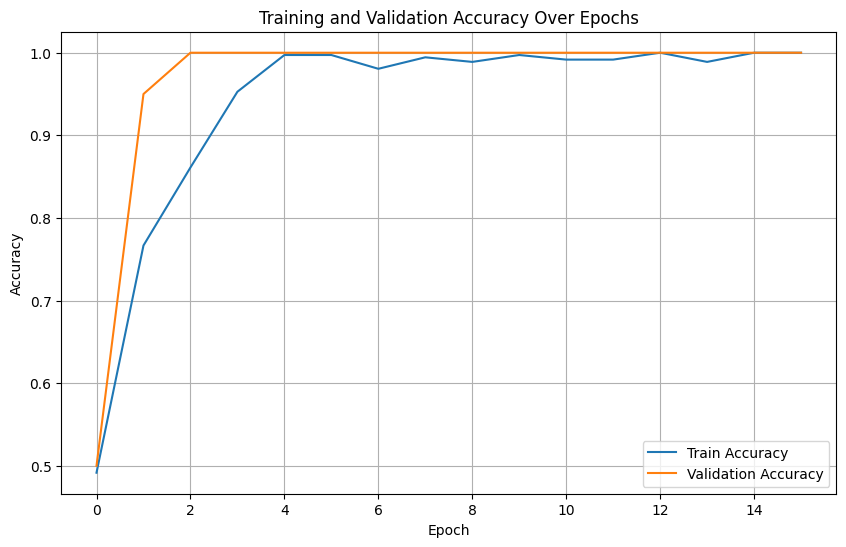

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

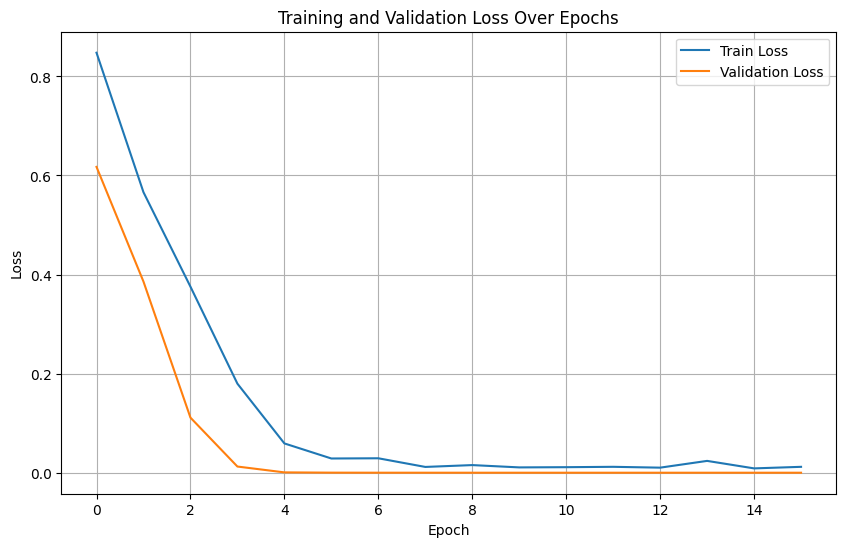

In [31]:


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix
val_predictions = model.predict(val_features)
val_predicted_labels = (val_predictions > 0.5).astype(int)
cm = confusion_matrix(val_labels, val_predicted_labels)
print("Confusion Matrix:")
print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step
Confusion Matrix:
[[30  0]
 [ 0 30]]
